#Defining the Problem Statement & Basic Metrics

**Problem Statement:**
“Determine which types of titles (Movies vs. TV shows, genres, countries) Netflix should invest in, based on historical release patterns, geographic distribution, and talent metrics.”

In [1]:
# importing Python libraries for data processing and visualization

import pandas as pd             # linear algebra
import numpy as np              # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/000/940/original/netflix.csv  # loading the input file from the given link

--2025-05-13 05:02:52--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/000/940/original/netflix.csv
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 3.169.201.14, 3.169.201.156, 3.169.201.165, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|3.169.201.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3399671 (3.2M) [text/plain]
Saving to: ‘netflix.csv.29’

netflix.csv.29      100%[===================>]   3.24M  --.-KB/s    in 0.08s   

2025-05-13 05:02:52 (38.6 MB/s) - ‘netflix.csv.29’ saved [3399671/3399671]



In [3]:
df = pd.read_csv('netflix.csv')     # reading the input file
df.head()                           # showing the first 5 rows of data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## **Dataset information**

In [4]:
# Data shape and basic info
print("Shape:", df.shape)        # (rows, columns)
print("\nData types:\n", df.dtypes)

Shape: (8807, 12)

Data types:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


*   The input file has 8807 Rows/Records and 12 Columns/Variables

*   All columns have datatype as 'object', except for release_year which has integer datatype

*   Director, cast, country, date_added, rating, duration variables have null values




In [5]:
# Statistical summary

#    – For numeric only:
print("\nNumeric summary:\n", df.describe())

#    – For all columns (including categories):
print("\nFull summary (all dtypes):\n", df.describe(include='all'))


Numeric summary:
        release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000

Full summary (all dtypes):
        show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  Movie  Zubaan  Rajiv Chilaka  David Attenborough   
freq         1   6131       1             19                  19   
mean       NaN    NaN     NaN            NaN                 NaN   
std        NaN    NaN     NaN            NaN                 NaN   
min        NaN    NaN     NaN            NaN                 NaN   
25%        NaN    NaN     NaN            NaN                 NaN   
50%        NaN    NaN     NaN            NaN                 NaN   
75%        NaN    NaN     NaN            NaN                 NaN   
max        NaN    NaN   

### Observations based on Summary

**Temporal Distribution of Content:**
* The only numerical variable shown is the release year. The dataset spans from 1925 to 2021. However, most titles are from recent years: the mean release year is about 2014, the median is 2017, and 75% of titles come from 2019 or later. This indicates that while there is some historical content, Netflix’s library is largely dominated by modern releases.

**Content Type Imbalance:**
* The dataset categorizes each record as either a Movie or a TV Show. There is a clear dominance of movies (with 6131 entries) compared to TV shows (~2676), suggesting that Netflix’s content pool is heavily weighted toward movies. This could reflect both acquisition strategy and viewer preferences.

**High Uniqueness Amidst Some Missing Data:**
* Every show has a unique identifier and unique title, underscoring that the dataset has no duplicate content entries.
* Key fields like “director” and “cast” have high diversity (with 4528 and 7692 unique values, respectively). However, there are noticeable missing values:
1. The director column is missing data for about 2634 records.
2. The cast and country fields have 825 and 831 missing values respectively.
* Other columns like “date_added” and “rating” are almost complete, though “rating” (with 17 unique values) and “duration” (220 unique entries) reflect a range of content categorizations.

**Categorical Diversity and Genre Tags:**
* The dataset includes rich categorical information. For example, the “listed_in” column (with 514 unique genre or category descriptors) implies that Netflix titles are tagged across many genres.
* The “rating” column is modest in diversity (only 17 unique ratings) with “TV-MA” being the most common value, which aligns with the observation that many titles are targeted for mature audiences.

**Data Integrity and Preprocessing Needs:**
* Although the data appears comprehensive, the presence of multi-valued cells in fields like “cast,” “director,” “country,” and “listed_in” suggests that further preprocessing (such as “exploding” these fields) might be needed for detailed analysis.
* Addressing the missing values (especially in director, cast, and country) is critical for any downstream analysis.
* Overall, the dataset is large (8807 records) and appears to be rich in diversity of content while focusing predominantly on movies in recent years. This mix offers ample opportunity for deeper analysis on trends, regional content variations, and genre or rating-specific behaviors.

## **Handling missing data and deleting duplicates**

In [6]:
# Missing-value detection
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


* The dataset contains missing values primarily in columns like Director, Cast, and Country. Since these fields are textual and sparsely populated, they were either left untouched or filled using domain-aware strategies (e.g. "Unknown" or forward-filling).

In [7]:
df[df.duplicated()]                  # to find if there are any duplicate rows of data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


There are no duplicate rows in this input file

In [8]:
df.drop_duplicates(inplace=True)    # deleting the duplicates if there are any duplicate rows of data

In [9]:
df['director'] = df['director'].fillna('No Data')                   # filling the missing values with 'No Data'
df['cast'] = df['cast'].fillna('No Data')                       # filling the missing values with 'No Data'
df['country'] = df['country'].fillna(df['country'].mode()[0])   # replacing the missing values with most common country

In [10]:
# Extract year from 'release_year'
df['release_year'] = pd.to_datetime(df['release_year'], format='%Y').dt.year

# Replace null values in 'date_added'
df['date_added'] = df['date_added'].fillna(pd.to_datetime(df['release_year'], format='%Y'))

In [11]:
null_values = df.isnull().sum()       # Checking The Missing Values
null_values[null_values > 0]

,0
rating,4
duration,3


# Outlier check

In [12]:
# Extract duration in minutes or number of seasons

# Create separate columns for movie duration
df['duration_minutes'] = df.apply(
lambda x: int(x['duration'].split()[0]) if pd.notnull(x['duration']) and x['type'] == 'Movie' else None,axis=1)

# For TV shows — extract number of seasons
df['Number_of_Seasons'] = df.apply(
lambda x: int(x['duration'].split()[0]) if pd.notnull(x['duration']) and x['type'] == 'TV Show' else None,axis=1)

In [13]:
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_minutes'] = pd.to_numeric(df_movies['duration'].str.extract(r'(\d+)')[0])

# Interquartile Range (IQR) method for movie durations
Q1 = df_movies['duration_minutes'].quantile(0.25)
Q3 = df_movies['duration_minutes'].quantile(0.75)
IQR = Q3 - Q1
# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df_movies[(df_movies['duration_minutes'] < lower_bound) | (df_movies['duration_minutes'] > upper_bound)]
outliers[['title', 'duration_minutes']].sort_values(by='duration_minutes',ascending=False).head(5)

,title,duration_minutes
4253,Black Mirror: Bandersnatch,312.0
717,Headspace: Unwind Your Mind,273.0
2491,The School of Mischief,253.0
2487,No Longer kids,237.0
2484,Lock Your Girls In,233.0


In [14]:
# Finding out top 5 longest and top 5 shortest movies
longest_outliers = df_movies[df_movies['duration_minutes'] > upper_bound]
longest_outliers = longest_outliers[['title', 'duration', 'duration_minutes']].sort_values(by='duration_minutes', ascending=False).head(5)
shortest_outliers = df_movies[df_movies['duration_minutes'] < lower_bound]
shortest_outliers = shortest_outliers[['title', 'duration', 'duration_minutes']].sort_values(by='duration_minutes').head(5)
outliers = pd.concat([longest_outliers, shortest_outliers])
outliers

,title,duration,duration_minutes
4253,Black Mirror: Bandersnatch,312 min,312.0
717,Headspace: Unwind Your Mind,273 min,273.0
2491,The School of Mischief,253 min,253.0
2487,No Longer kids,237 min,237.0
2484,Lock Your Girls In,233 min,233.0
3777,Silent,3 min,3.0
2713,Sol Levante,5 min,5.0
1484,Cops and Robbers,8 min,8.0
1557,Canvas,9 min,9.0
3535,American Factory: A Conversation with the Obamas,10 min,10.0


* Outliers in duration_minutes were detected using the IQR method.
* Films with durations significantly shorter or longer than the typical range were flagged.
* These may represent special content (e.g., short films, stand-up specials) and were retained rather than removed to preserve data integrity.

In [15]:
df['rating'].unique()                # checking the unique values of the column

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [16]:
df['rating'] = df['rating'].replace({'74 min':'TV-MA','84 min': 'TV-MA', '66 min': 'TV-MA'})  # correcting the values by checking the Maturity rating online
df['rating'] = df['rating'].replace({'TV-Y7-FV':'TV-Y7'})                                     # replacing the incorrect values
df['rating'] = df['rating'].replace({np.nan:'No Data'})                                       # replacing the missing values

In [17]:
print(df.loc[df['rating'] == 'No Data', 'title'])

5989    13TH: A Conversation with Oprah Winfrey & Ava ...
6827                    Gargantia on the Verdurous Planet
7312                                         Little Lunch
7537                                 My Honor Was Loyalty
Name: title, dtype: object


In [18]:
# Converting to category type to reduce memory usage
df['director'] = df['director'].astype('category')
df['cast'] = df['cast'].astype('category')


df.drop('description', axis=1, inplace=True)  #removing the unwanted column to reduce memory usage

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   show_id            8807 non-null   object  
 1   type               8807 non-null   object  
 2   title              8807 non-null   object  
 3   director           8807 non-null   category
 4   cast               8807 non-null   category
 5   country            8807 non-null   object  
 6   date_added         8807 non-null   object  
 7   release_year       8807 non-null   int32   
 8   rating             8807 non-null   object  
 9   duration           8804 non-null   object  
 10  listed_in          8807 non-null   object  
 11  duration_minutes   6128 non-null   float64 
 12  Number_of_Seasons  2676 non-null   float64 
dtypes: category(2), float64(2), int32(1), object(8)
memory usage: 1.2+ MB


In [20]:
# Replacing the missing values with the misalignied data
df.loc[df['title'].str.contains('Louis C.K. 2017', na=False), 'duration'] = '74 min'
df.loc[df['title'].str.contains('Louis C.K.: Hilarious', na=False), 'duration'] = '84 min'
df.loc[df['title'].str.contains('Louis C.K.: Live at the Comedy Store', na=False), 'duration'] = '66 min'

df.loc[df['title'].str.contains('My Honor Was Loyalty', na=False), 'rating'] = 'PG-13'
df.loc[df['title'].str.contains('Little Lunch', na=False), 'rating'] = 'TV-G'
df.loc[df['title'].str.contains('Gargantia on the Verdurous Planet', na=False), 'rating'] = 'TV-14'

In [21]:
print(df.loc[df['rating'] == 'No Data', 'title'])

5989    13TH: A Conversation with Oprah Winfrey & Ava ...
Name: title, dtype: object


In [22]:
df.loc[df['rating'].str.contains('No Data', na=False), 'rating'] = 'PG-13'

In [23]:
df['added_year'] = pd.DatetimeIndex(df['date_added']).year         # Creating new columns

In [24]:
df.info()                             # Checking The Missing Values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   show_id            8807 non-null   object  
 1   type               8807 non-null   object  
 2   title              8807 non-null   object  
 3   director           8807 non-null   category
 4   cast               8807 non-null   category
 5   country            8807 non-null   object  
 6   date_added         8807 non-null   object  
 7   release_year       8807 non-null   int32   
 8   rating             8807 non-null   object  
 9   duration           8807 non-null   object  
 10  listed_in          8807 non-null   object  
 11  duration_minutes   6128 non-null   float64 
 12  Number_of_Seasons  2676 non-null   float64 
 13  added_year         8807 non-null   int32   
dtypes: category(2), float64(2), int32(2), object(8)
memory usage: 1.2+ MB


* Missing/Null Values are taken care of.

In [25]:
# Source used : https://help.netflix.com/en/node/2064 , using the source for simplifying our data for better understanding

df['rating'] = df['rating'].replace({
                            'TV-MA' : 'Adults',
                            'R'     : 'Adults',
                            'NC-17' : 'Adults',
                            'TV-14' : 'Teens',
                            'PG-13' : 'Teens',
                            'TV-Y7' : 'Kids',
                            'PG'    : 'Kids',
                            'TV-PG' : 'Kids',
                            'TV-Y'  : 'Kids',
                            'TV-G'  : 'Kids',
                            'G'     : 'Kids',
                            'NR'    : 'Not Rated',
                            'UR'    : 'Not Rated'})

In [26]:
df['rating'].unique()                # checking the unique values of the column again

array(['Teens', 'Adults', 'Kids', 'Not Rated'], dtype=object)

### **Observation**
* We have multiple data in each cell of the 4 columns: Cast, Director, Country and Listed_In
* Pre-processing (unnesting) is required


# Pre-Processing, Non-Graphical Analysis and Visualizations

# **KPI_1:** Movies vs. TV Shows

In [27]:
# Non-Graphical Analysis

# Count occurrences of each type
count_type = df['type'].value_counts()
print(count_type)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


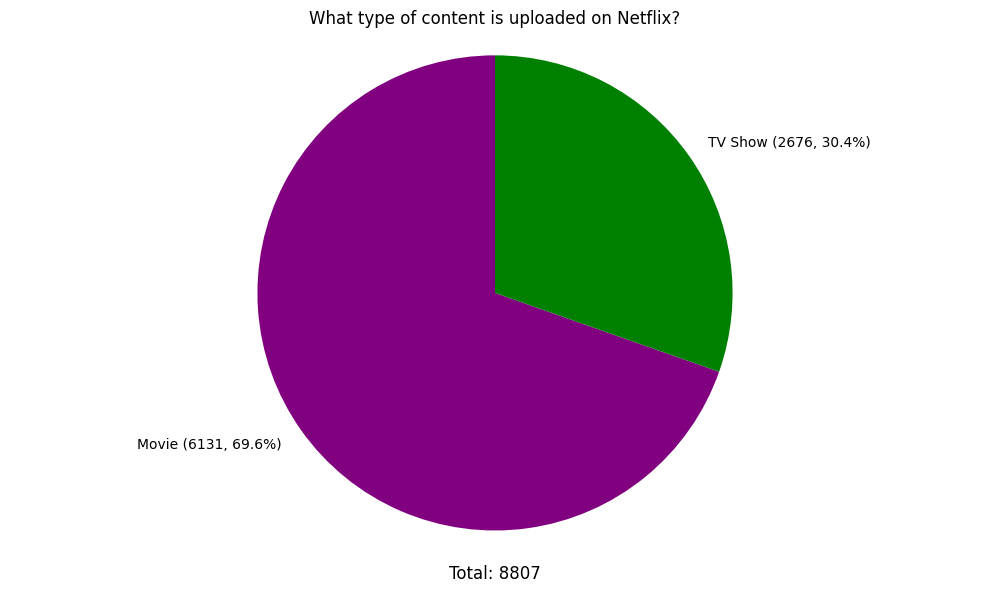

In [28]:
# Visualization

# Labels with counts and percentages
labels = [f'{label} ({count}, {count / count_type.sum() *100:.1f}%)'
        for label, count in zip (count_type.index, count_type.values)]

# Create the pie chart
plt.figure(figsize=(10,6))
plt.pie(count_type, labels=labels, autopct=None, startangle=90, colors=['purple','green'])
plt.title('What type of content is uploaded on Netflix?')
plt.axis('equal')

# Add total count at the bottom
total_count = count_type.sum()
plt.text(0, -1.2, f'Total: {total_count}', ha='center', fontsize=12)

# Equal aspect ratio ensures the pie is circular
plt.tight_layout()
plt.show()

### **Observations:**

* **Movie Dominance:** The pie chart clearly shows that Movies constitute a larger portion of the content uploaded on Netflix.

* **Movie to TV Show Ratio:** The approximate ratio of "Movie : TV Show" is around 70% : 30%. This indicates that there are significantly more movies available on Netflix compared to TV shows.

### **Insights:**

1. **Content Acquisition Strategy:** The dominance of movies suggests that Netflix's content acquisition strategy might be focused on acquiring movie licenses. This could be due to various factors such as the wider availability of movie licenses, the popularity of movies among viewers, or the perceived value of movies in attracting new subscribers.

2. **User Preferences:** The data might reflect user preferences, indicating that Netflix users generally prefer watching movies over TV shows. This could be because movies offer a more self-contained and shorter viewing experience compared to TV shows, which often require a longer-term commitment.

3. **Content Investment Decisions:** The distribution of content types could influence Netflix's content investment decisions. While original movies and TV shows are a significant part of Netflix's strategy, the pie chart suggests that acquiring movie licenses might still be a priority.

### **Recommendations:**

* **Maintain Movie Focus:** Netflix should continue to focus on acquiring and producing movies, as they constitute a major portion of its content library and are likely popular among users.

* **Strategic TV Show Investment:** While movies are dominant, Netflix should strategically invest in producing and acquiring high-quality TV shows to cater to the segment of users who prefer this format. This could involve focusing on genres that are popular among TV show viewers, such as drama, comedy, and thrillers.

* **Original Content Balance:** Netflix should strive to maintain a balance between original and licensed content for both movies and TV shows. This would ensure a diverse and engaging content library that appeals to a wide range of user preferences.

* **Data-Driven Optimization:** Netflix should continuously monitor user engagement with both movies and TV shows to optimize its content acquisition and production strategies based on data-driven insights.

# **KPI_2:** Top 10 countries by count

In [29]:
# splitting the columns (Cast, Director, Country and Listed_In) with multiple data in different rows

# Create a copy to safely split and explode
df_explode_raw = df.copy()

In [30]:
#Pre-processing - Unnesting of the data in column "Country"
df_explode_raw['country'] = df_explode_raw['country'].str.split(",")
df_explode_raw = df_explode_raw.explode('country')
df_explode_raw['country'] = df_explode_raw['country'].str.strip()  # Strip whitespaces
df_explode_raw['country'].value_counts().head()

# Non-Graphical Analysis for top 10 countries

top_10_countries = df_explode_raw['country'].value_counts().head(10).index
filtered_df_1 = df_explode_raw[df_explode_raw['country'].isin(top_10_countries)]
country_counts_by_type = filtered_df_1.groupby(['country', 'type'])['type'].count().reset_index(name='count')
total_counts = country_counts_by_type.groupby('country')['count'].sum().reset_index(name='total_count')
country_counts_by_type = pd.merge(country_counts_by_type, total_counts, on='country')
country_counts_by_type['Percentage'] = ((country_counts_by_type['count'] / country_counts_by_type['total_count']) * 100).round(1)
country_counts_by_type = country_counts_by_type.sort_values(by=['total_count'], ascending=False)

print(country_counts_by_type)

           country     type  count  total_count  Percentage
18   United States    Movie   3192         4521        70.6
19   United States  TV Show   1329         4521        29.4
6            India    Movie    962         1046        92.0
7            India  TV Show     84         1046         8.0
17  United Kingdom  TV Show    272          806        33.7
16  United Kingdom    Movie    534          806        66.3
1           Canada  TV Show    126          445        28.3
0           Canada    Movie    319          445        71.7
3           France  TV Show     90          393        22.9
2           France    Movie    303          393        77.1
9            Japan  TV Show    199          318        62.6
8            Japan    Movie    119          318        37.4
14           Spain    Movie    171          232        73.7
15           Spain  TV Show     61          232        26.3
12     South Korea    Movie     61          231        26.4
13     South Korea  TV Show    170      

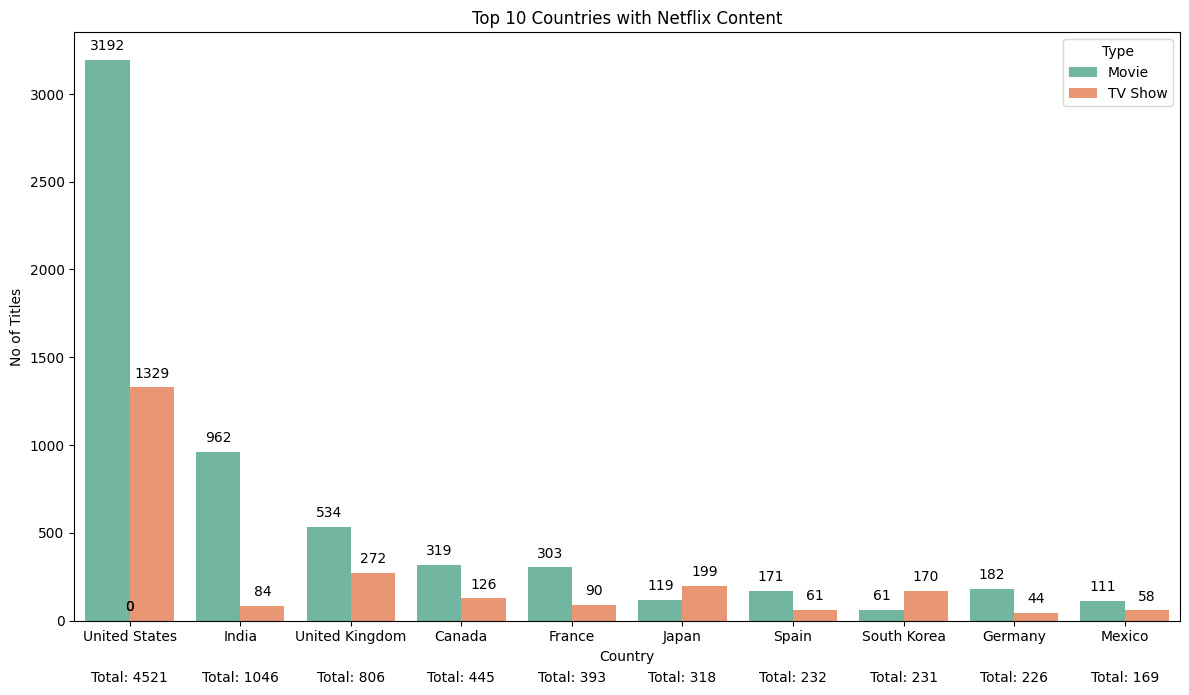

In [31]:
# Visualization
plt.figure(figsize=(12, 7))
ax = sns.countplot(data= filtered_df_1 , x='country', hue='type', palette='Set2', order=top_10_countries)
plt.title("Top 10 Countries with Netflix Content")
plt.xlabel("Country")
plt.ylabel("No of Titles")
#plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.legend(title='Type')

# Add value labels to the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')


# Calculate and add country totals below the x-axis
for i, country in enumerate(top_10_countries):
    total_count = filtered_df_1[filtered_df_1['country'] == country]['type'].count()
    ax.text(i,-350, f'Total: {total_count}', ha='center', fontsize=10)

plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

###**Observations:**

* **United States Dominance:** The United States has the highest number of Netflix titles, indicating a significant focus on the US market.

* **India's Movie Preference:** India has a large number of titles, but the majority are movies. This suggests a strong preference for Bollywood and other Indian film content among Indian Netflix subscribers.

* **South Korea's TV Show Focus:** While South Korea has a smaller overall content library compared to the US or India, a substantial portion consists of TV shows, highlighting the popularity of Korean dramas (K-dramas) on Netflix.

* **United Kingdom and Canada:** These countries have a balanced mix of movies and TV shows, catering to diverse viewer preferences.

* **Other Countries:** Countries like France, Japan, Spain, Egypt, and Turkey also have a presence on Netflix, although with smaller content libraries compared to the top countries.

###**Insights:**

1. **Content Strategy by Region:** Netflix's content strategy appears to be tailored to regional preferences, with a focus on movies in India and TV shows in South Korea. This localized approach helps Netflix attract and retain subscribers in different markets.

2. **Global Expansion:** Netflix is expanding its global reach by offering content from various countries, although the US remains a primary focus.

3. **Genre Preferences:** The graph provides insights into genre preferences across countries, suggesting potential areas for content investment. For example, Netflix could invest in more Indian movies or Korean TV shows to cater to the demand in those regions.

4. **Competition:** The presence of titles from various countries could reflect Netflix's efforts to compete with local streaming services and traditional media in those markets.

5. **Cultural Exchange:** Netflix's platform facilitates cultural exchange by exposing viewers to content from different countries, promoting global understanding and diversity.

###**Recommendations:**

* **Continue Regional Focus:** Netflix should continue to invest in localized content to cater to regional preferences, as this has been a key driver of its success in different markets.

* **Expand Content Diversity:** Netflix can further expand its content diversity by including titles from more countries, exploring diverse genres, and offering a wider range of languages.

* **Promote Cross-Cultural Content:** Netflix can encourage the discovery of content from different countries through recommendations, curated lists, and targeted marketing efforts, fostering cultural exchange and understanding.

* **Data-Driven Decision-Making:** Netflix should continue to leverage data analytics to understand user preferences and trends, ensuring that its content strategy remains aligned with viewer demand.

# **KPI_3:** Total titles, per year growth rate and Average Release Delay

In [32]:
# Non-Graphical Analysis

Titles_released = df['release_year'].value_counts().sort_index(ascending=False).head(15)
print(Titles_released)

release_year
2021     592
2020     953
2019    1030
2018    1147
2017    1032
2016     902
2015     560
2014     352
2013     288
2012     237
2011     185
2010     194
2009     152
2008     136
2007      88
Name: count, dtype: int64


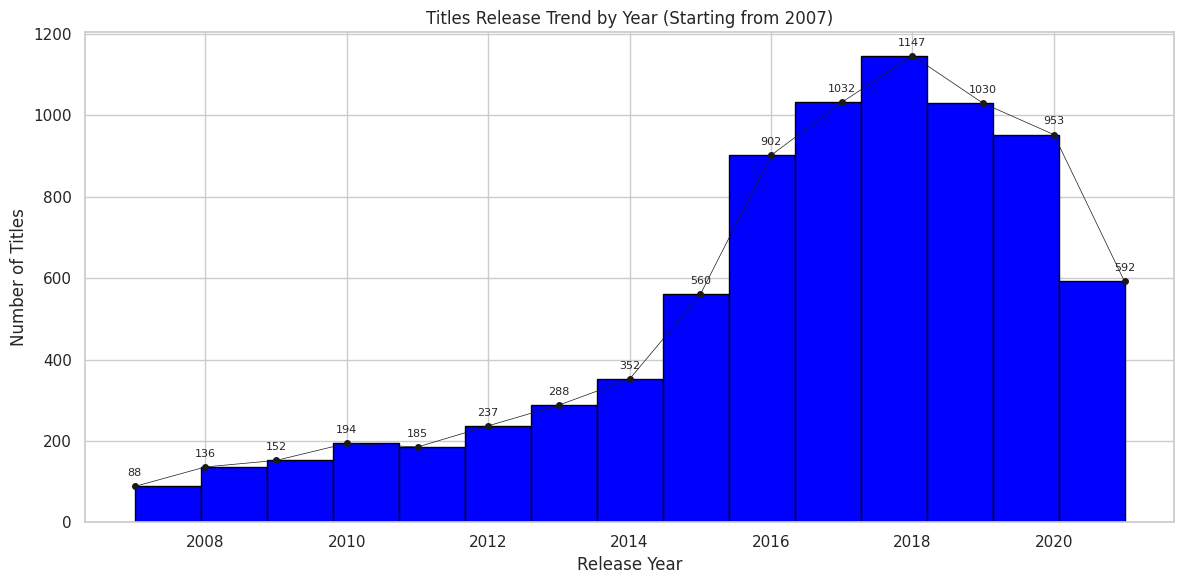

In [33]:
# Using Histogram:

# Filter data for release years starting from 2007
filtered_df_2 = df[df['release_year'] >= 2007]

# Create the histogram using filtered data
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
plt.hist(filtered_df_2['release_year'], bins=15, color='blue', edgecolor='black')

# Get x and y values for plotting
x_values = filtered_df_2['release_year'].value_counts().sort_index().index
y_values = filtered_df_2['release_year'].value_counts().sort_index().values

# Plot the line connecting the dots
plt.plot(x_values, y_values, 'k-', linewidth=0.5)  # 'k-' for black line

# Add black dots and display values for each dot
for x, y in zip(x_values, y_values):
    plt.plot(x, y, 'ko', markersize=4)  # 'ko' for black dots
    plt.text(x, y + 20, str(y), ha='center', va='bottom', fontsize=8)  # Display values

plt.title('Titles Release Trend by Year (Starting from 2007)')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
#plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

* Netflix launched its streaming service in 2007. Initially, user growth was slow, but it began to accelerate significantly around 2014. By 2018, the volume of content on the platform had grown to 13 times that of 2007.

* However, starting in 2019, content availability began to decline. This drop coincides with two major factors: the onset of the COVID-19 pandemic and the launch of Disney+ in 2019. Many popular titles, especially from Marvel and other Disney-owned studios, were shifted to Disney+, reducing Netflix's content library.

In [34]:
# Non-Graphical Analysis

Titles_added = df['added_year'].value_counts().sort_index(ascending=False).head(15)
print(Titles_added)

added_year
2021    1498
2020    1879
2019    2016
2018    1650
2017    1188
2016     430
2015      84
2014      24
2013      12
2012       4
2011      13
2010       2
2009       2
2008       3
2003       2
Name: count, dtype: int64


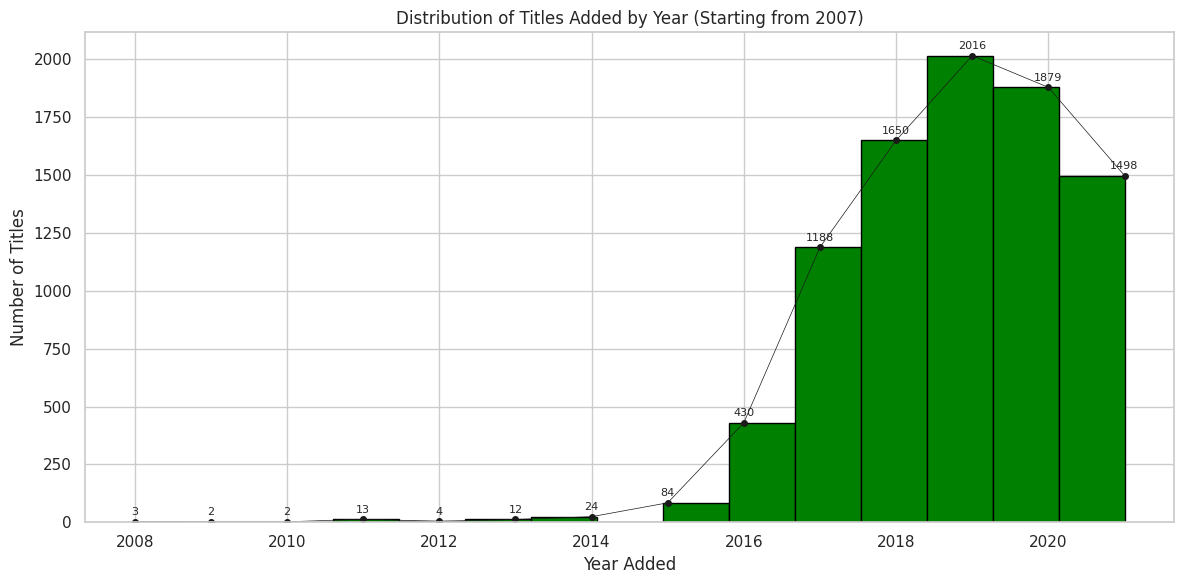

In [35]:
# Using Histogram:

# Filter data for release years starting from 2007
filtered_df_3 = df[df['added_year'] >= 2007]

# Create the histogram using filtered data
plt.figure(figsize=(12, 6))
plt.hist(filtered_df_3['added_year'], bins=15, color='green', edgecolor='black')

# Get x and y values for plotting
x_values = filtered_df_3['added_year'].value_counts().sort_index().index
y_values = filtered_df_3['added_year'].value_counts().sort_index().values

# Plot the line connecting the dots
plt.plot(x_values, y_values, 'k-', linewidth=0.5)  # 'k-' for black line

# Add black dots and display values for each dot
for x, y in zip(x_values, y_values):
    plt.plot(x, y, 'ko', markersize=4)  # 'ko' for black dots
    plt.text(x, y + 20, str(y), ha='center', va='bottom', fontsize=8)  # Display values

plt.title('Distribution of Titles Added by Year (Starting from 2007)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
#plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

*   While new releases declined, the number of titles added to Netflix continued to increase until 2019, indicating a focus on acquiring existing content. However, this trend also shows a decline in subsequent years.



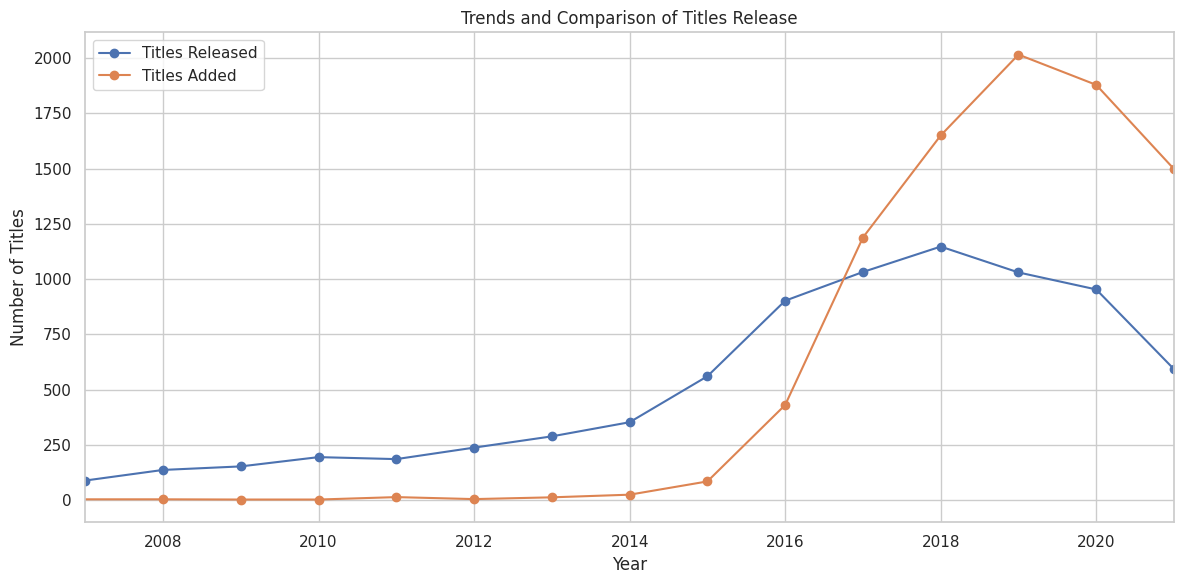

In [36]:
# Group data by year and count titles for filtered_df_2
trend_df2 = filtered_df_2.groupby('release_year')['title'].count().reset_index()
trend_df2.rename(columns={'title': 'count_df2'}, inplace=True)

# Group data by year and count titles for filtered_df_3
trend_df3 = filtered_df_3.groupby('added_year')['title'].count().reset_index()
trend_df3.rename(columns={'title': 'count_df3'}, inplace=True)

# Merge the two DataFrames on year
merged_trend_df = pd.merge(trend_df2, trend_df3, left_on='release_year', right_on='added_year', how='outer')

# Fill NaN values with 0 for plotting
merged_trend_df.fillna(0, inplace=True)

# Create the line graph
plt.figure(figsize=(12, 6))  # Adjust figure size as needed

plt.plot(merged_trend_df['release_year'], merged_trend_df['count_df2'], label='Titles Released', marker='o')
plt.plot(merged_trend_df['added_year'], merged_trend_df['count_df3'], label='Titles Added', marker='o')

plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.title('Trends and Comparison of Titles Release')
plt.legend()
plt.grid(True)
# Set x-axis limits to start from 2007
plt.xlim(2007, merged_trend_df['release_year'].max())
plt.tight_layout()
plt.show()

###**Observations:**

* **2018 Peak:** 2018 marks the peak for both titles released and titles added, suggesting a period of rapid expansion for Netflix's content library.

* **Post-2019 Shift:** The decline in both metrics after 2019 could be attributed to factors such as the launch of competing streaming services (like Disney+) and production challenges during the COVID-19 pandemic.

* **Release vs. Addition:** Before 2019, the gap between titles released and titles added was widening, indicating Netflix was adding more existing content than producing new ones. This gap narrows in subsequent years, suggesting a potential shift in content strategy.

###**Insights and Potential Implications:**

1. **Competition:** The launch of competing streaming services has likely impacted Netflix's content strategy, leading to a focus on retaining existing subscribers and potentially reducing investments in new productions.

2. **Production Challenges:** The COVID-19 pandemic posed challenges for content production, contributing to the decline in new releases.
Content Strategy: Netflix might be shifting its focus towards original content and licensing agreements to maintain its content library in the face of competition.

3. **User Engagement:** The changes in content trends might influence user engagement and subscription patterns. Monitoring these trends is crucial for Netflix to understand user preferences and adapt its strategy accordingly.

###**Recommendations:**

* **Original Content Focus:** Given the decline in licensed content, Netflix should further prioritize the development and production of high-quality original content to differentiate itself from competitors and attract new subscribers.

* **Strategic Licensing:** Netflix should continue to pursue strategic licensing agreements for popular titles, but with a greater emphasis on securing exclusive rights whenever possible.

* **Diversification:** Explore new content formats, genres, and interactive experiences to engage viewers and offer unique value propositions.
Data-Driven Decisions: Continuously analyze user data to understand content preferences and viewing habits to inform content acquisition and production decisions.

* **Global Expansion:** Continue expanding into new markets to offset potential saturation in existing regions.

* **Adaptability:** Remain flexible and adaptable to industry changes, emerging technologies, and evolving viewer expectations.

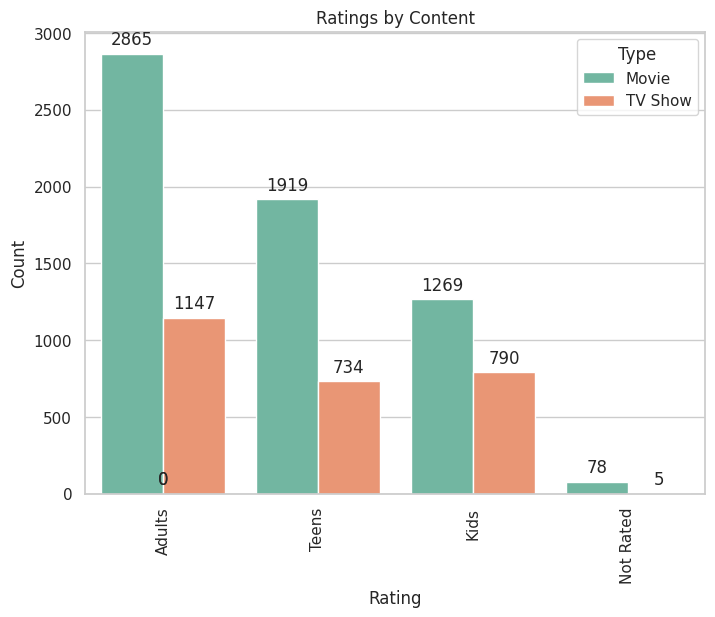

In [37]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='rating', hue='type', palette='Set2', order=df['rating'].value_counts().index)

plt.title("Ratings by Content")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.legend(title='Type')

# Add value labels to the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

### **Observations**
* **Adults Content:** The most frequent content rating is "Adults," encompassing both movies and TV shows. This is understandable as it covers a wide range of mature content, catering to a larger audience segment.

* **Mature Content Dominance:** Within the "Adults" rating, Movies have a slightly higher count compared to TV Shows. This indicates that more adult-oriented content is available in the movie format on Netflix.

* **Teens and Kids Content:** "Teens" is the second most frequent rating category, followed by "Kids." This distribution aligns with Netflix's strategy of offering content suitable for various age groups.

* **Movie Preference in Teens:** For the "Teens" rating, there's a noticeable preference for Movies over TV Shows. This could suggest that teenagers on Netflix are more inclined to watch movies in this rating category.

* **Balanced Kids Content:** In the "Kids" rating, the count of Movies and TV Shows is more balanced. This indicates a diverse range of content for younger viewers in both formats.

* **Not Rated Content:** The number of "Not Rated" titles is relatively small, suggesting that Netflix primarily focuses on content with clear and established ratings.

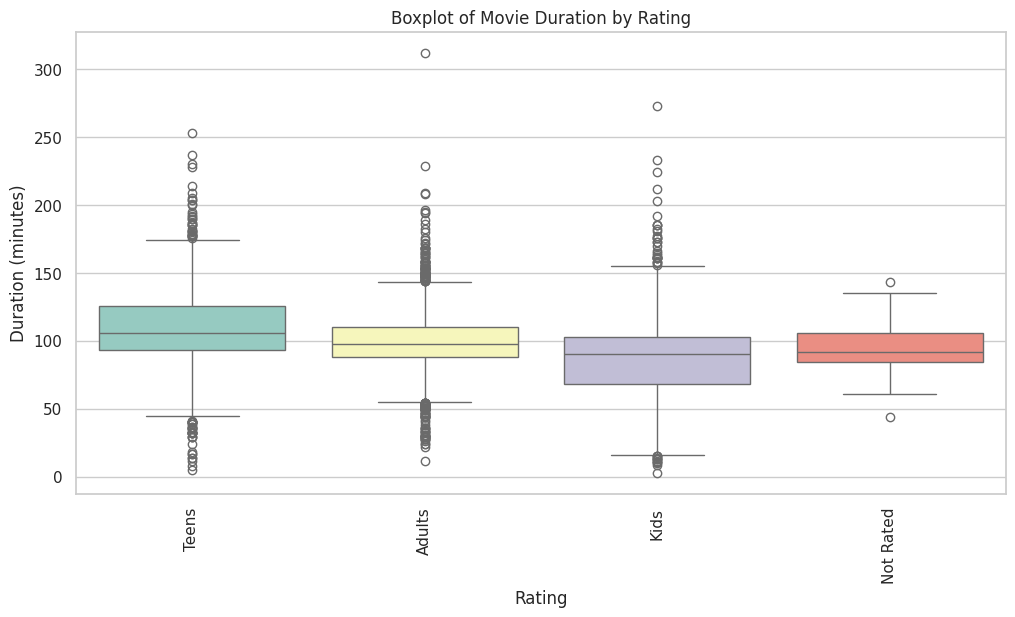

In [38]:
# 1. Boxplot of Movie Duration by Rating (only for movies with duration in minutes)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='rating', y='duration_minutes', hue='rating', palette='Set3', legend=False)
plt.title("Boxplot of Movie Duration by Rating")
plt.xlabel("Rating")
plt.ylabel("Duration (minutes)")
plt.xticks(rotation=90)
plt.show()

###**Observations:**

| Rating        | Median Duration | IQR (25th–75th pct) | Notable Outliers                                                                          |
| ------------- | --------------- | ------------------- | ----------------------------------------------------------------------------------------- |
| **Teens**     | \~105 min       | \~95–125 min        | A handful of very short (< 30 min) titles and some extremely long (> 250 min) outliers.   |
| **Adults**    | \~98 min        | \~88–110 min        | A few very short (< 15 min) and long (> 230 min) titles.                                  |
| **Kids**      | \~85 min        | \~70–100 min        | Many sub-15 min “outliers” (likely animated shorts), plus some long specials (\~270 min). |
| **Not Rated** | \~90 min        | \~85–105 min        | Some very short (< 45 min) and longer (\~145 min) titles.                                 |

* **Spreads:**
Teens and Adults show the widest IQRs, indicating more variety in length for “family-to-mature” audiences.
Kids’ durations cluster lower, but the long tail of outliers suggests a mix of short cartoons and occasional feature-length specials.

* **Consistency:**
Not Rated content is relatively consistent around ~90 min, making it a sweet spot for general audiences.

###**Insights:**
1. **Target Runtime by Audience:**
Kids clearly prefer shorter runtimes (medians sub-90 min); anything over 2 hours is atypical and likely special events.
Teen viewers tolerate and perhaps seek longer “binge-style” films (median > 100 min with many stretching past 2 hours).

2. **Content Variety:**
The wide IQR for Adults suggests programming that spans quick documentaries (~90 min) up to epic features (> 2 hours).

3. **Outlier Programming:**
Very short and very long outliers in all categories may represent shorts, episodic content, or director’s-cuts—valuable for niche marketing but not core lineup.

###**Recommendations:**
* **Optimize Kids’ Content Length:**
Primary slate: 30–90 min titles to match the tight IQR and keep engagement high.
Special events: Market longer titles (120+ min) as “event premieres” rather than everyday fare.

* **Tiered Teen & Adult Offerings:**
For Teens, lean into 100–130 min as standard films, but include a “long-form” collection (150+ min) for epic storytelling.
For Adults, maintain a diverse lineup: short docs (~60 min) and blockbusters (120–180 min).

* **Leverage “Not Rated” Format:**
Since Not Rated content clusters tightly around ~90 min, promote it as “easy picks” for general audiences looking for dependable runtimes.

* **Curate Outliers Strategically:**
Short-form content (< 30 min) can live in a dedicated “Quick Watch” or “Kids’ Shorts” section.
Extended cuts (> 180 min) are best showcased in “Director’s Cut” or “Film Festivals” collections to set viewer expectations.

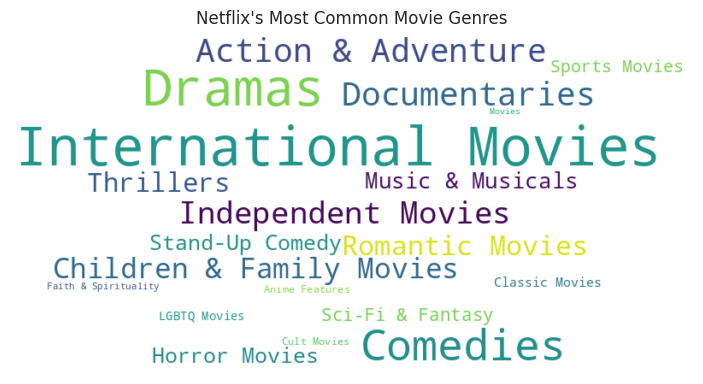

Top 10 Movie Genres:
International Movies: 2752
Dramas: 2427
Comedies: 1674
Documentaries: 869
Action & Adventure: 859
Independent Movies: 756
Children & Family Movies: 641
Romantic Movies: 616
Thrillers: 577
Music & Musicals: 375


In [39]:
from collections import Counter
from wordcloud import WordCloud
# Filter only movies
movies = df[df['type'] == 'Movie']

# Drop missing genres and split genre strings into individual genres
movie_genres_series = movies['listed_in'].dropna().str.split(', ')
movie_genres_flat = [genre for sublist in movie_genres_series for genre in sublist]

# Count frequency of each genre
genre_counts = Counter(movie_genres_flat)

# Generate and display the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis')
wordcloud.generate_from_frequencies(genre_counts)
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Netflix's Most Common Movie Genres")
plt.tight_layout()
plt.show()
# Print top 10 genres
print("Top 10 Movie Genres:")
for genre, count in genre_counts.most_common(10):
  print(f"{genre}: {count}")

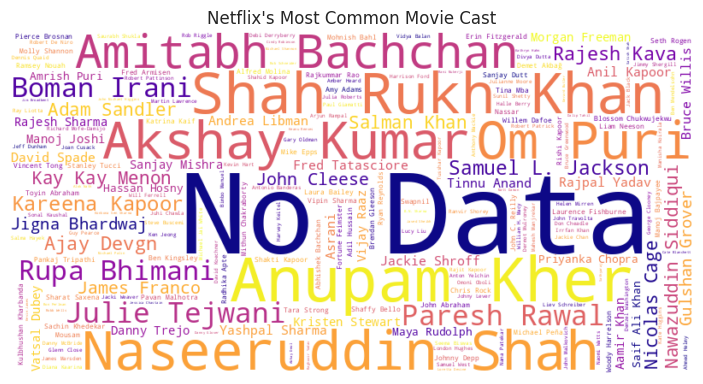

Top 10 Movie Casts:
No Data: 475
Anupam Kher: 42
Shah Rukh Khan: 35
Naseeruddin Shah: 32
Akshay Kumar: 30
Om Puri: 30
Amitabh Bachchan: 28
Julie Tejwani: 28
Paresh Rawal: 28
Rupa Bhimani: 27


In [40]:
from collections import Counter
from wordcloud import WordCloud
# Filter only movies
movies = df[df['type'] == 'Movie']

# Drop missing genres and split genre strings into individual genres
movie_cast_series = movies['cast'].dropna().str.split(', ')
movie_cast_flat = [genre for sublist in movie_cast_series for genre in sublist]

# Count frequency of each genre
movie_cast_counts = Counter(movie_cast_flat)

# Generate and display the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma')
wordcloud.generate_from_frequencies(movie_cast_counts)
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Netflix's Most Common Movie Cast")
plt.tight_layout()
plt.show()
# Print top 10 genres
print("Top 10 Movie Casts:")
for cast, count in movie_cast_counts.most_common(10):
  print(f"{cast}: {count}")

### **Correlation Heatmap & Pairplot**
* The heatmap shows how numeric features relate to each other. For example, if release_year and duration_minutes have a weak correlation, it indicates movie length hasn't trended up or down over time.
* The pairplot helps identify potential linear or nonlinear relationships between numeric variables. It also gives a quick view of distributions and clustering patterns.

In [41]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(numeric_cols)

['release_year', 'duration_minutes', 'Number_of_Seasons', 'added_year']


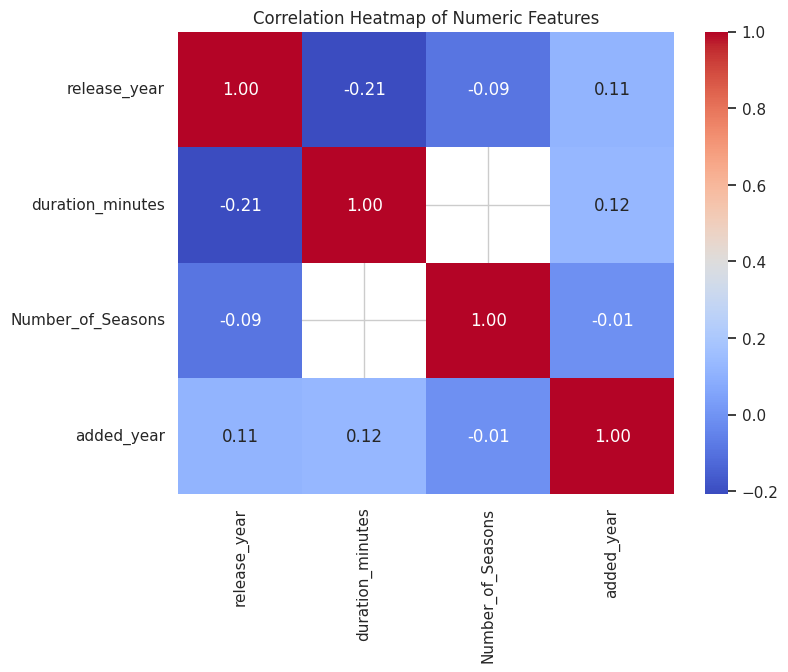

In [42]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

###**Observations**

| Pair                                  | Correlation | Interpretation                                                                             |
| ------------------------------------- | ----------: | ------------------------------------------------------------------------------------------ |
| **release\_year ⇄ duration\_minutes** |       –0.21 | Slight negative: newer titles tend to be a bit shorter on average.                         |
| **release\_year ⇄ seasons**           |       –0.09 | Essentially no relationship: how many seasons a series has isn’t tied to its release date. |
| **release\_year ⇄ added\_year**       |       +0.11 | Weak positive: generally, more recent productions are added sooner.                        |
| **duration\_minutes ⇄ added\_year**   |       +0.12 | Slight positive: longer titles skew toward being added later.                              |
| **seasons ⇄ added\_year**             |       –0.01 | No meaningful link between # of seasons and when a show lands.                             |


* All correlations hover near zero. There are no strong linear trends among these numeric fields.

### **Insights**
* **Independent Features:**
Since none of these features move in lock-step, each brings its own unique signal.

* **Runtime Trends:**
A mild trend toward shorter runtimes in newer content suggests modern attention spans or production choices favor tighter pacing.

* **Acquisition Lag:**
The modest positive link between release_year and added_year indicates the platform adds very recent titles faster—likely due to licensing priorities.

* **Seasons Are Unpredictable:**
You can’t predict how many seasons a show has based on release or acquisition timing—it’s driven more by creative/contractual factors than timing.

### **Recommendations**
* **Focus on Licensing Pipeline:**
Since recent-release titles get onto the service faster, pipeline metrics (time from theatrical release to streaming) could be a strong operational KPI.


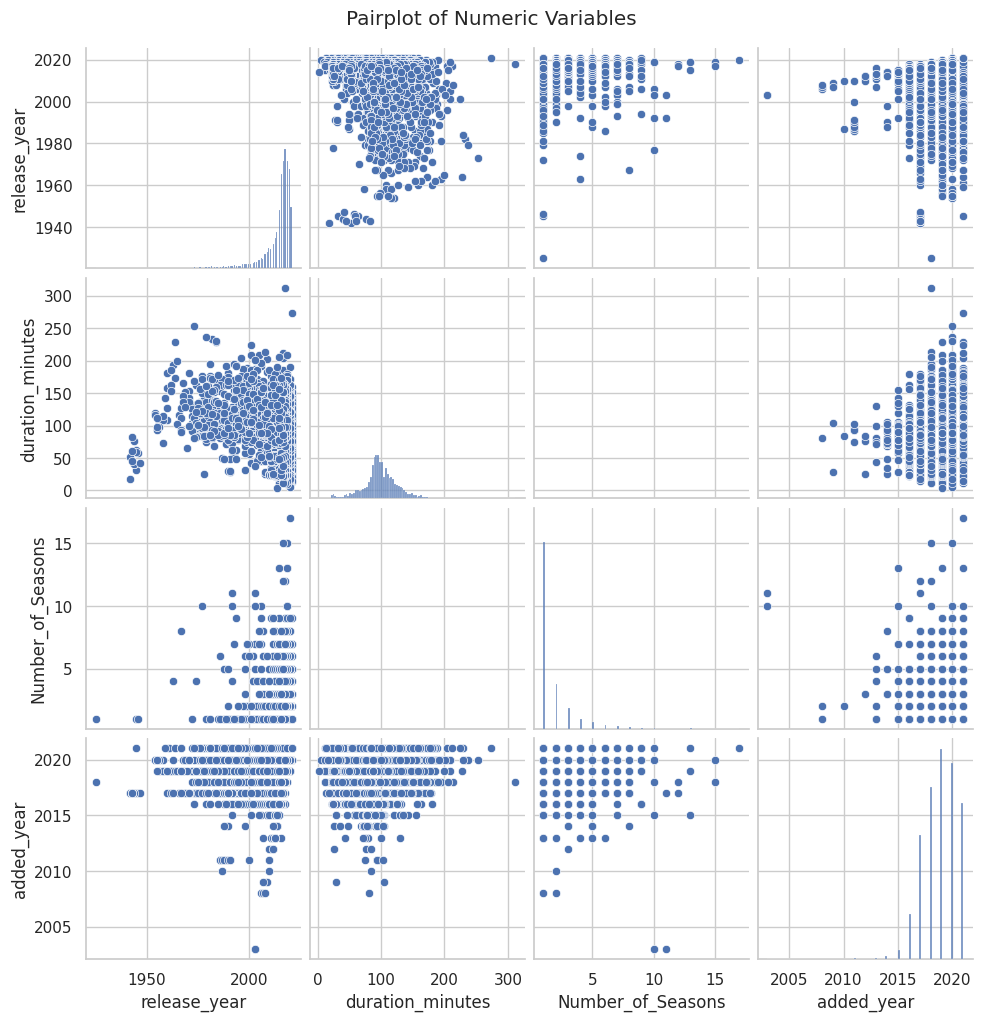

In [43]:
sns.pairplot(df[numeric_cols])
plt.suptitle("Pairplot of Numeric Variables", y=1.02)
plt.show()

### **Observations**
* **Release Year Distribution:**
The vast majority of titles were released after 2000, with a big surge around 2015–2020.
A long thin tail extends back into the 1950s–1990s, but those are comparatively rare.

* **Duration Distribution:**
Durations cluster tightly around 80–140 minutes, with very few titles below 30 min (shorts) or above 250 min (epics).A slight skew toward shorter runtimes in more recent releases (denser low-duration cloud around 2018–2020).

* **Number of Seasons:**
Most Among series, 1–3 seasons dominate; very few long-running shows exceed 5 seasons.

* **Added Year:**
Almost every title was added between 2017 and 2020, with a peak around 2018–2019.
Very few legacy titles added before 2015.

* **Pairwise Relationships:-**
***Release Year vs. Duration:** a gentle downward trend—newer titles tend to be a bit shorter on average.
***Release Year vs. Added Year:** nearly linear (points sit just above the diagonal), showing the platform adds recent releases quickly.
***Duration vs. Seasons:** two distinct clusters—vertical line at 0 seasons (movies of all lengths) and a cloud at ≥1 season (shorter individual episode runtimes).
***Seasons vs. Added Year:** no clear trend—series with many seasons have been added across all years 2017–2020.

### **Insights**

1. **Content Freshness:**
You are heavily skewed toward recent content, both in production (release_year) and acquisition (added_year). Users browsing older eras may find slim pickings.

2. **Runtime Norms:**
The “sweet spot” for feature films is 90–120 minutes, and most series episodes are under 60 minutes.


3. **Recency Bias:**
With so much content added in 2018–2019, engagement metrics will naturally favor those releases—beware attributing high viewership to quality rather than recency.

### **Recommendations**
* **Revive Older Titles:**
Since older releases and additions are under-represented, run a “Retro Spotlight” campaign to drive discovery of pre-2000 content and expand the long tail.

* **Enrich Features:**
Because these numeric fields are largely uncorrelated, layer in genre, rating, and user-behavior signals (e.g. click-through, watch-time) to build richer predictive models and personalization.